In [2]:
import pandas as pd

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('../../datasets/Skyserver_SQL2_27_2018 6_51_39 PM.csv')
df.head()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512


In [4]:
df.shape

(10000, 18)

In [5]:
df['class'].unique()

array(['STAR', 'GALAXY', 'QSO'], dtype=object)

In [6]:
df.groupby(['class']).size()

class
GALAXY    4998
QSO        850
STAR      4152
dtype: int64

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(['objid', 'specobjid', 'class'], axis=1)
Y = df['class']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, shuffle=True)

In [8]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(max_depth=2).fit(x_train, y_train)

In [9]:
y_pred = dt_model.predict(x_test)

In [10]:
pred_results = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})

In [11]:
pred_results.head()

,y_test,y_pred
8881,GALAXY,GALAXY
5147,STAR,STAR
720,GALAXY,GALAXY
4411,GALAXY,GALAXY
1582,STAR,STAR


In [12]:
df_crosstab = pd.crosstab(pred_results.y_pred, pred_results.y_test)
df_crosstab

y_test,GALAXY,QSO,STAR
y_pred,,,
GALAXY,1008,17,1
QSO,3,156,0
STAR,6,0,809


In [13]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')

print("Acurácia : ", accuracy)
print("Precisão : ", precision)
print("Recall : ", recall)

Acurácia :  0.9865
Precisão :  0.9865
Recall :  0.9865


In [15]:
from sklearn import tree
text_representation = tree.export_text(dt_model, decimals=4)
print(text_representation)

|--- feature_11 <= 0.0015
|   |--- feature_2 <= 19.5888
|   |   |--- class: STAR
|   |--- feature_2 >  19.5888
|   |   |--- class: STAR
|--- feature_11 >  0.0015
|   |--- feature_11 <= 0.2136
|   |   |--- class: GALAXY
|   |--- feature_11 >  0.2136
|   |   |--- class: QSO



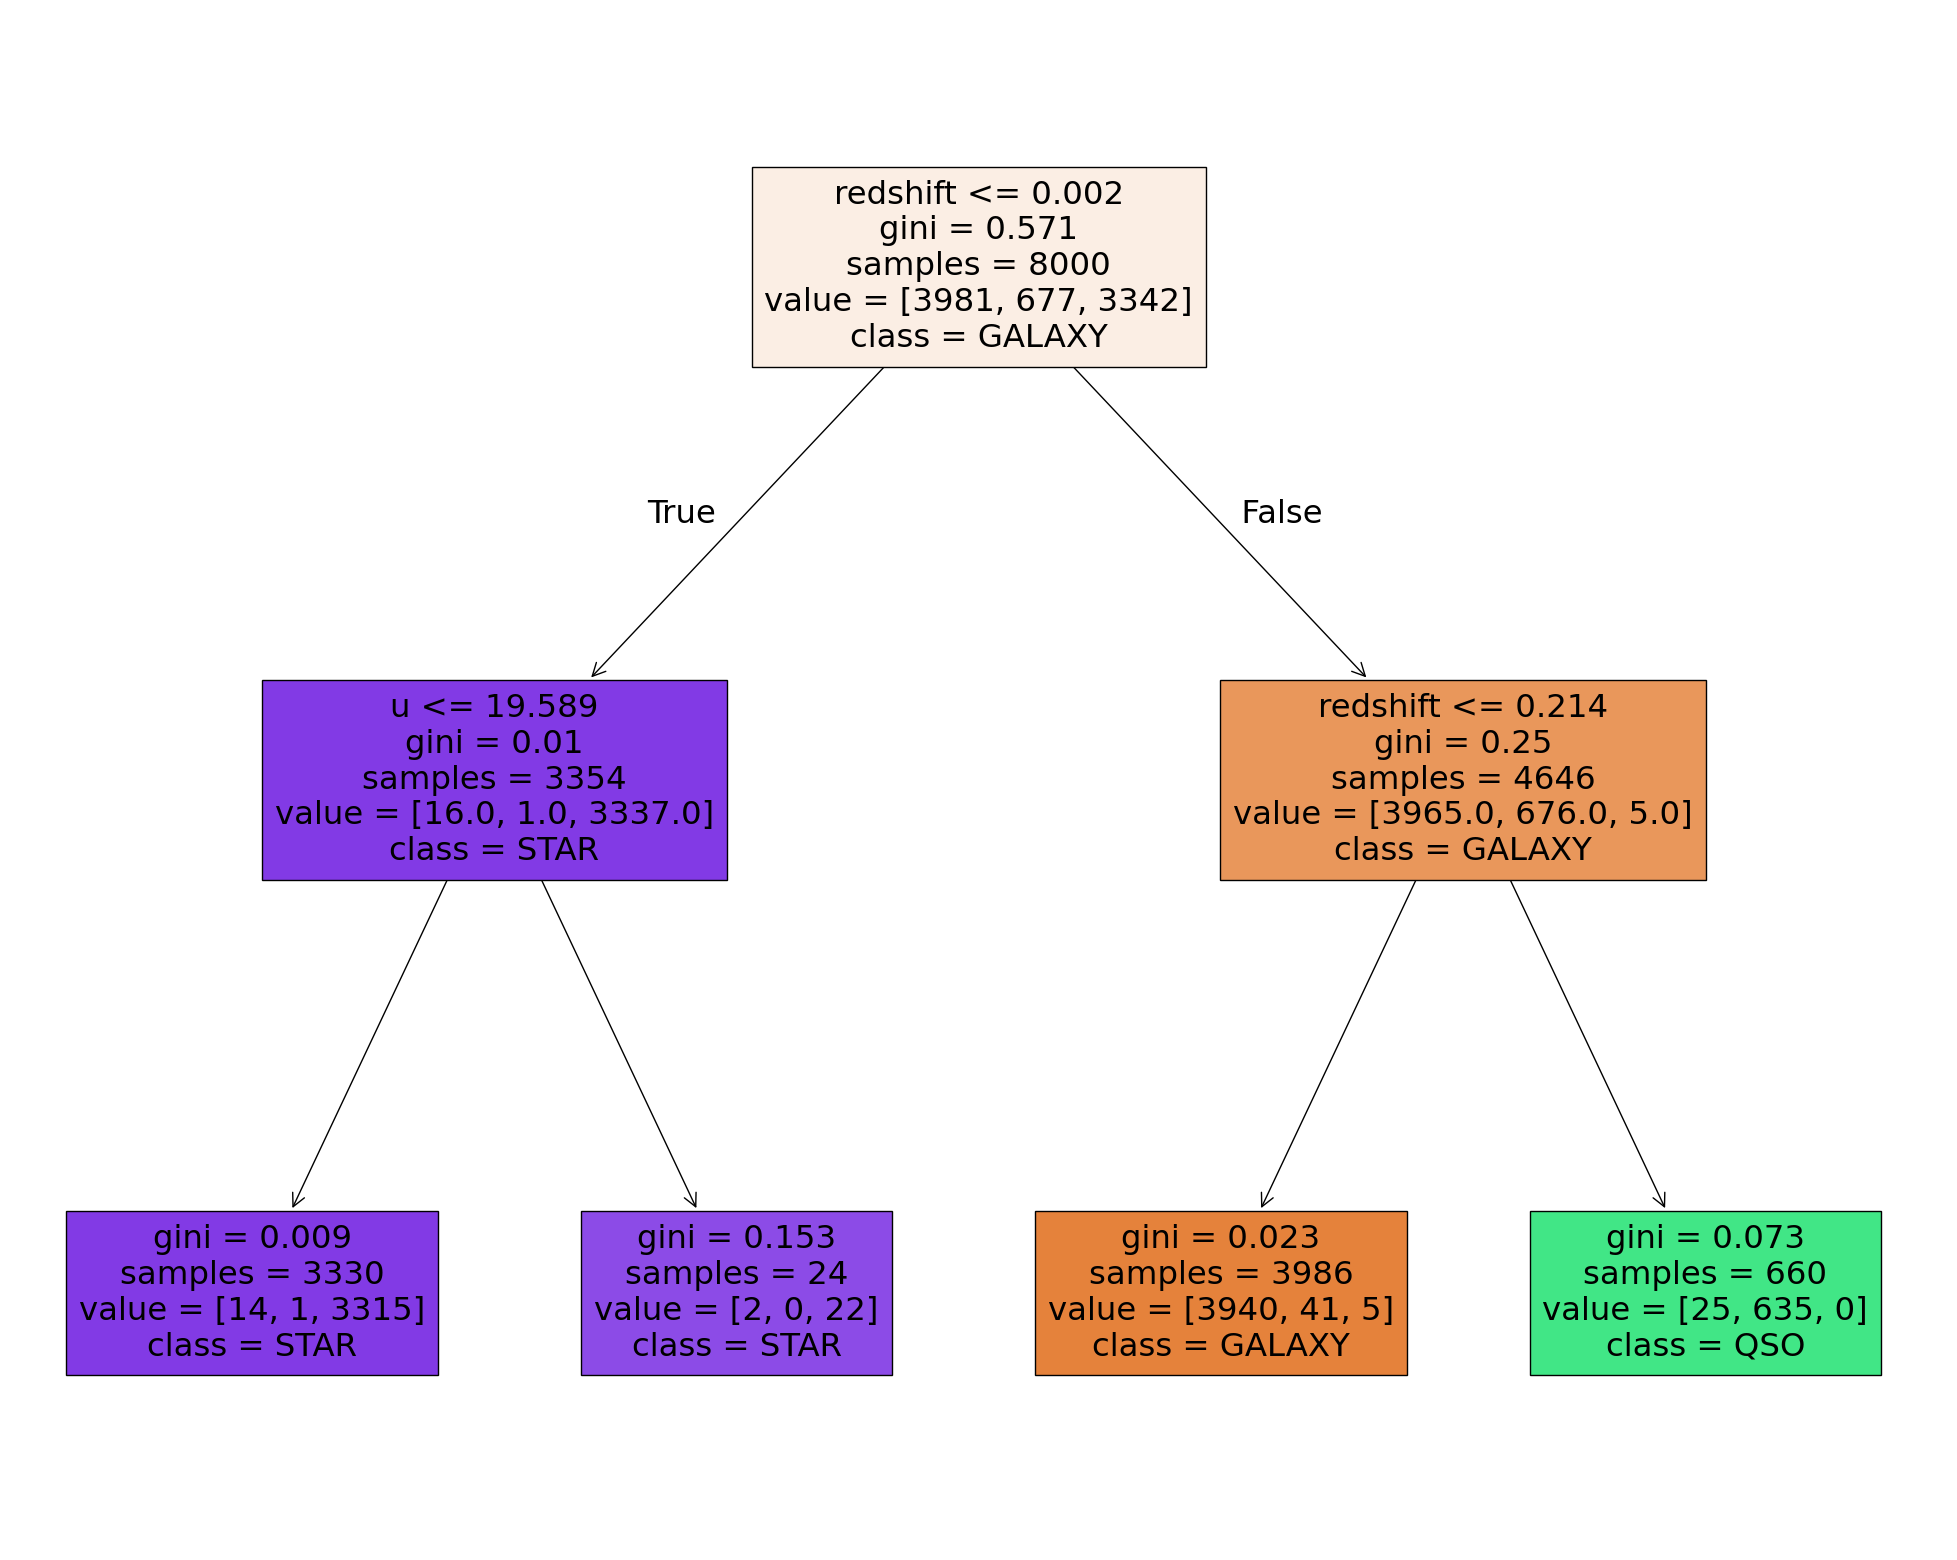

In [16]:
import matplotlib.pyplot as plt

dt_feature_names = list(X.columns)
dt_target_names = [str(s) for s in sorted(Y.unique())]

fig = plt.figure(figsize=(25,20))
plt = tree.plot_tree(dt_model, feature_names=dt_feature_names, class_names=dt_target_names, filled=True)

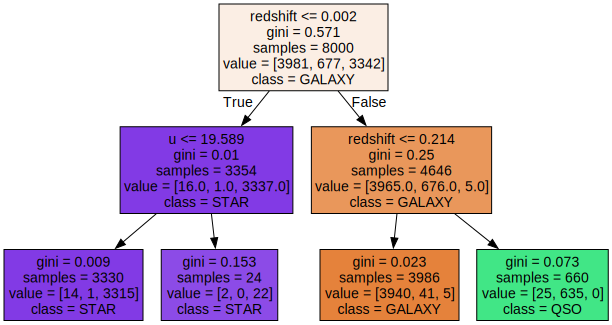

In [17]:
import os
os.environ["PATH"] += os.pathsep + "C:\\Program Files\\Graphviz\\bin"

# Para instalar wordcloud, abra um terminal e execute [pip install wordcloud]
import graphviz

dot_data = tree.export_graphviz(dt_model, out_file=None, feature_names=dt_feature_names, class_names=dt_target_names, \
                                filled=True)

graph = graphviz.Source(dot_data, format="png") 
graph

In [18]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(max_depth=3).fit(x_train, y_train)

In [19]:
y_pred = dt_model.predict(x_test)

In [20]:
pred_results = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})

In [21]:
pred_results.head()

,y_test,y_pred
8881,GALAXY,GALAXY
5147,STAR,STAR
720,GALAXY,GALAXY
4411,GALAXY,GALAXY
1582,STAR,STAR


In [22]:
df_crosstab = pd.crosstab(pred_results.y_pred, pred_results.y_test)
df_crosstab

y_test,GALAXY,QSO,STAR
y_pred,,,
GALAXY,1005,16,3
QSO,6,157,0
STAR,6,0,807


In [23]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [24]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')

print("Acurácia : ", accuracy)
print("Precisão : ", precision)
print("Recall : ", recall)

Acurácia :  0.9845
Precisão :  0.9845
Recall :  0.9845


In [25]:
from sklearn import tree
text_representation = tree.export_text(dt_model, decimals=4)
print(text_representation)

|--- feature_11 <= 0.0015
|   |--- feature_2 <= 19.5888
|   |   |--- feature_11 <= 0.0000
|   |   |   |--- class: STAR
|   |   |--- feature_11 >  0.0000
|   |   |   |--- class: STAR
|   |--- feature_2 >  19.5888
|   |   |--- feature_11 <= -0.0004
|   |   |   |--- class: GALAXY
|   |   |--- feature_11 >  -0.0004
|   |   |   |--- class: STAR
|--- feature_11 >  0.0015
|   |--- feature_11 <= 0.2136
|   |   |--- feature_3 <= 18.8103
|   |   |   |--- class: GALAXY
|   |   |--- feature_3 >  18.8103
|   |   |   |--- class: QSO
|   |--- feature_11 >  0.2136
|   |   |--- feature_11 <= 0.2649
|   |   |   |--- class: QSO
|   |   |--- feature_11 >  0.2649
|   |   |   |--- class: QSO



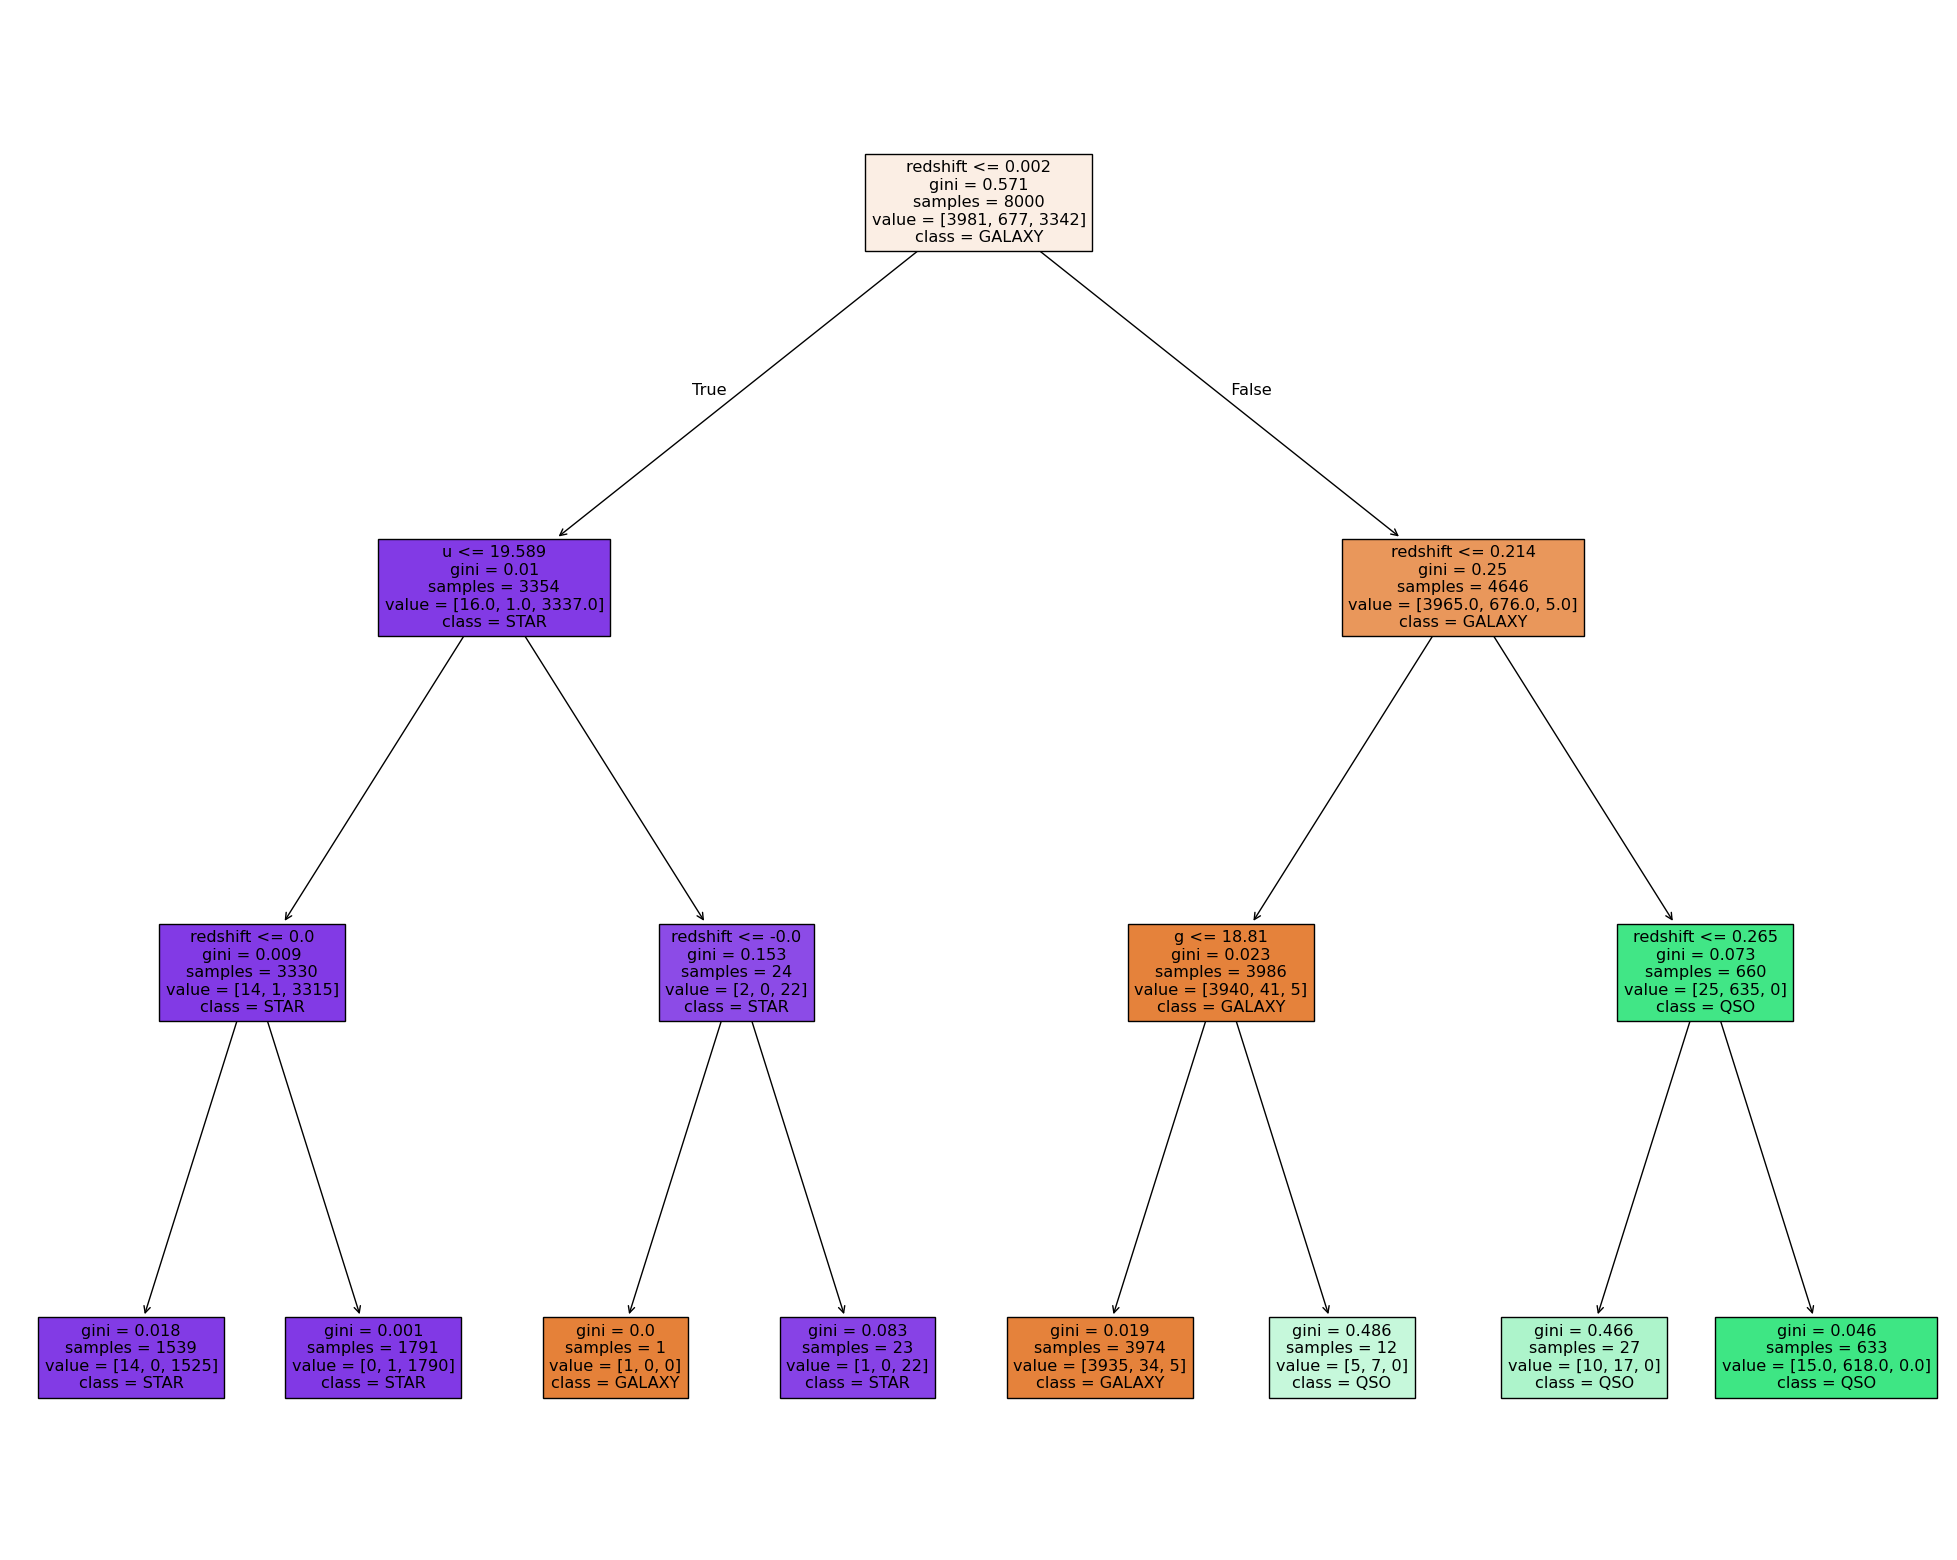

In [26]:
import matplotlib.pyplot as plt

dt_feature_names = list(X.columns)
dt_target_names = [str(s) for s in sorted(Y.unique())]

fig = plt.figure(figsize=(25,20))
plt = tree.plot_tree(dt_model, feature_names=dt_feature_names, class_names=dt_target_names, filled=True)

Acurácia :  0.984
Precisão :  0.984
Recall :  0.984
|--- feature_11 <= 0.0015
|   |--- feature_2 <= 19.5888
|   |   |--- feature_11 <= 0.0000
|   |   |   |--- feature_11 <= -0.0000
|   |   |   |   |--- feature_9 <= 1.5000
|   |   |   |   |   |--- feature_14 <= 563.0000
|   |   |   |   |   |   |--- class: STAR
|   |   |   |   |   |--- feature_14 >  563.0000
|   |   |   |   |   |   |--- feature_6 <= 15.3331
|   |   |   |   |   |   |   |--- class: GALAXY
|   |   |   |   |   |   |--- feature_6 >  15.3331
|   |   |   |   |   |   |   |--- class: STAR
|   |   |   |   |--- feature_9 >  1.5000
|   |   |   |   |   |--- class: STAR
|   |   |   |--- feature_11 >  -0.0000
|   |   |   |   |--- class: GALAXY
|   |   |--- feature_11 >  0.0000
|   |   |   |--- feature_11 <= 0.0005
|   |   |   |   |--- class: STAR
|   |   |   |--- feature_11 >  0.0005
|   |   |   |   |--- feature_11 <= 0.0005
|   |   |   |   |   |--- class: QSO
|   |   |   |   |--- feature_11 >  0.0005
|   |   |   |   |   |--- class: ST

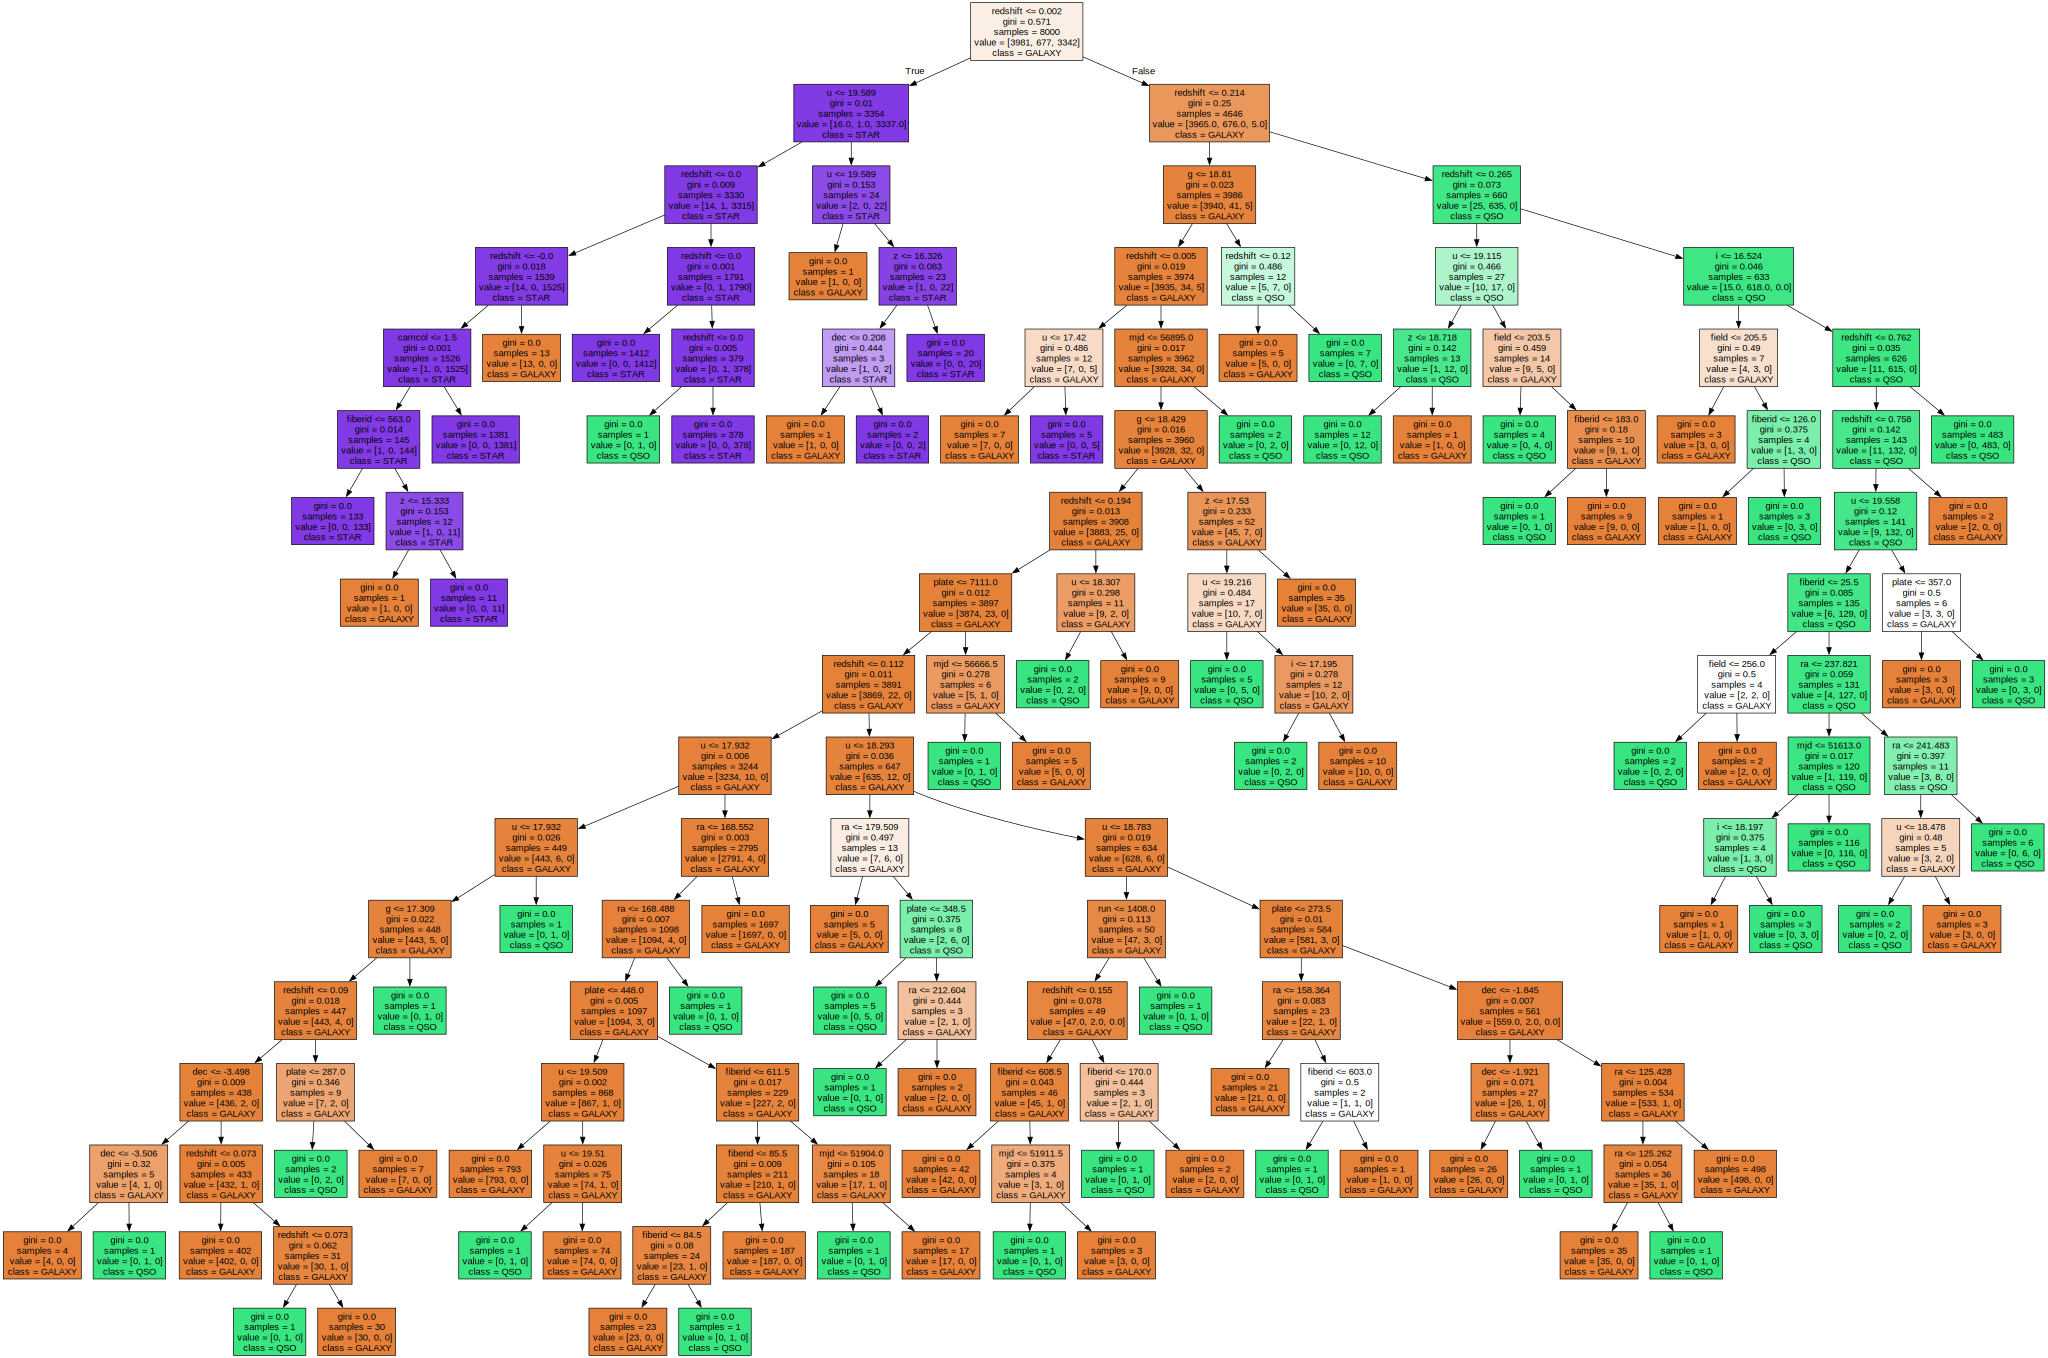

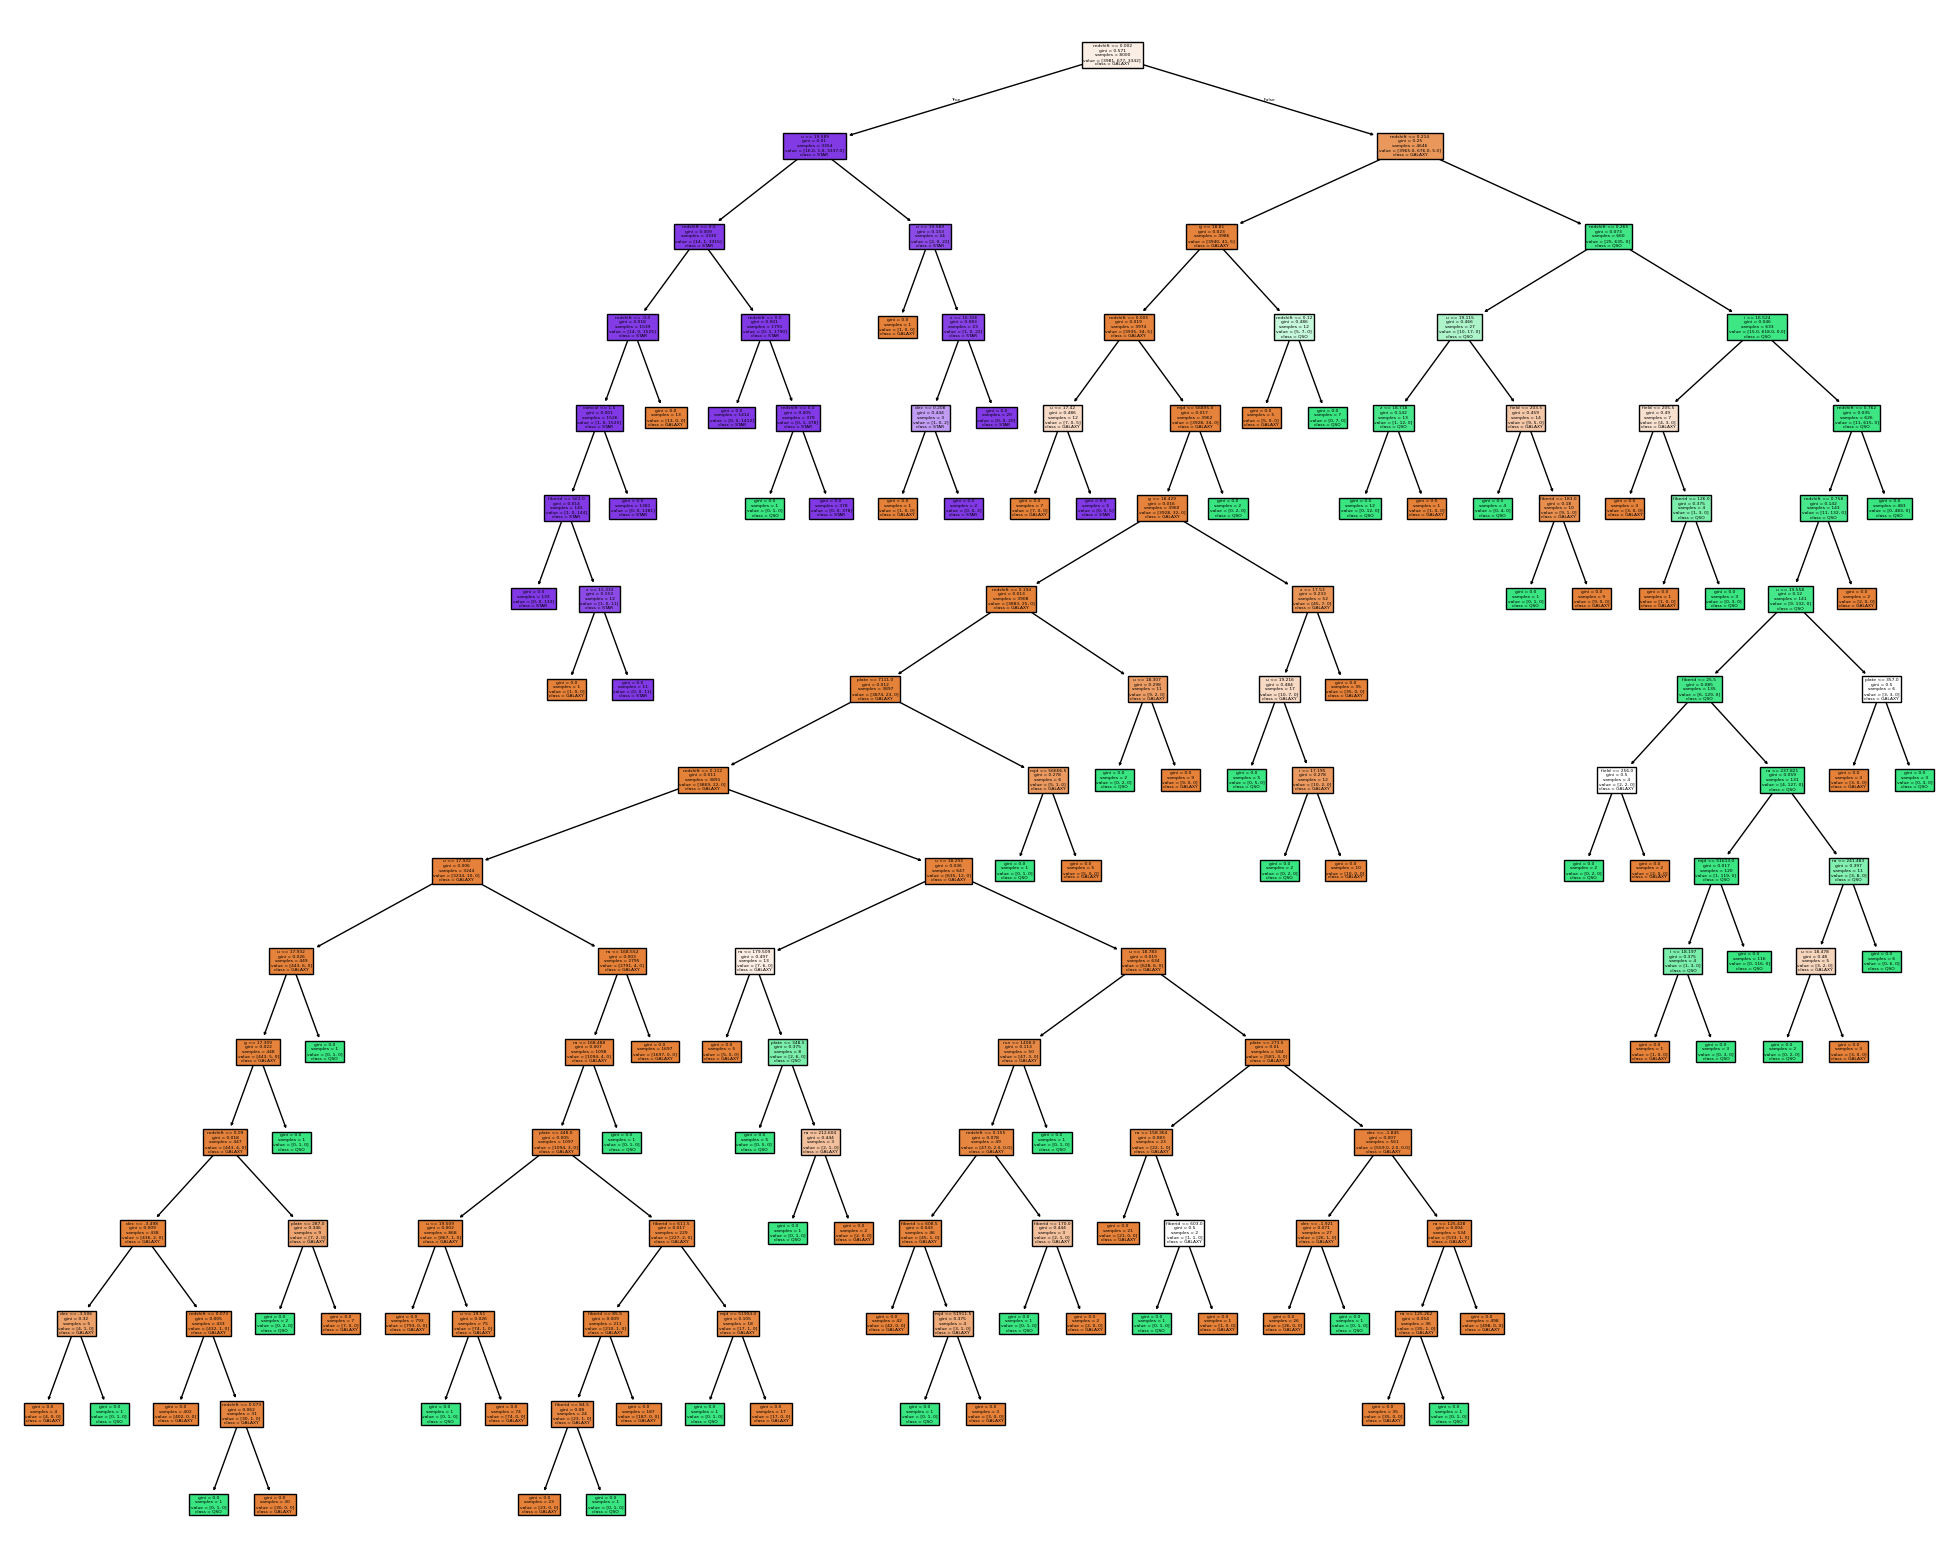

In [36]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier().fit(x_train, y_train)


y_pred = dt_model.predict(x_test)

pred_results = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})


pred_results.head()

df_crosstab = pd.crosstab(pred_results.y_pred, pred_results.y_test)
df_crosstab

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')

print("Acurácia : ", accuracy)
print("Precisão : ", precision)
print("Recall : ", recall)

from sklearn import tree
text_representation = tree.export_text(dt_model, decimals=4)
print(text_representation)

import matplotlib.pyplot as plt

dt_feature_names = list(X.columns)
dt_target_names = [str(s) for s in sorted(Y.unique())]

fig = plt.figure(figsize=(25,20))
plt = tree.plot_tree(dt_model, feature_names=dt_feature_names, class_names=dt_target_names, filled=True)

import os
os.environ["PATH"] += os.pathsep + "C:\\Program Files\\Graphviz\\bin"

# Para instalar wordcloud, abra um terminal e execute [pip install wordcloud]
import graphviz

dot_data = tree.export_graphviz(dt_model, out_file=None, feature_names=dt_feature_names, class_names=dt_target_names, \
                                filled=True)

graph = graphviz.Source(dot_data, format="png") 
graph